# Week 2 Lab: ML Fundamentals & Tabular ML
## Spaceship Titanic

**Objective:** Build an end-to-end machine learning pipeline to predict which passengers aboard the Spaceship Titanic were transported to an alternate dimension.

**Dataset:** Spaceship Titanic (Kaggle)
Download: [https://www.kaggle.com/competitions/spaceship-titanic/data](https://www.kaggle.com/competitions/spaceship-titanic/data)


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

# If you need to install xgboost: !pip install xgboost

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv("train.csv")

## Part 1: Load & Explore

The goal here is to understand what you're working with before touching any models.


### 1.1 First look
Run the following and note what you see.

In [3]:
df.shape

(8693, 14)

In [4]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
df.dtypes

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

In [6]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


**Q1:** How many rows and features does the dataset have? Which column is the target?

### 1.2 Missing values

In [7]:
df.isnull().sum().sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

In [8]:
df.isna().mean().sort_values(ascending=False) * 100

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
FoodCourt       2.105142
Spa             2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
PassengerId     0.000000
Transported     0.000000
dtype: float64

**Q2:** Which features have missing values? Roughly what percentage of each is missing?

### 1.3 Target distribution

In [9]:
df['Transported'].value_counts(normalize=True)

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

**Q3:** Is the target balanced or imbalanced? Will this affect your choice of metric?

### 1.4 Visual exploration

Create at least two plots to explore the data. Some ideas:
- Distribution of a spending column (e.g., `RoomService`, `Spa`, `VRDeck`)
- `HomePlanet` vs `Transported` (bar chart or grouped counts)
- Correlation heatmap of the numerical features
- Distribution of `Age`

**Hint:** `df['column'].hist()`, `sns.heatmap()`, `pd.crosstab()`, and `sns.countplot()` are your friends.

array([[<Axes: title={'center': 'RoomService'}>,
        <Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

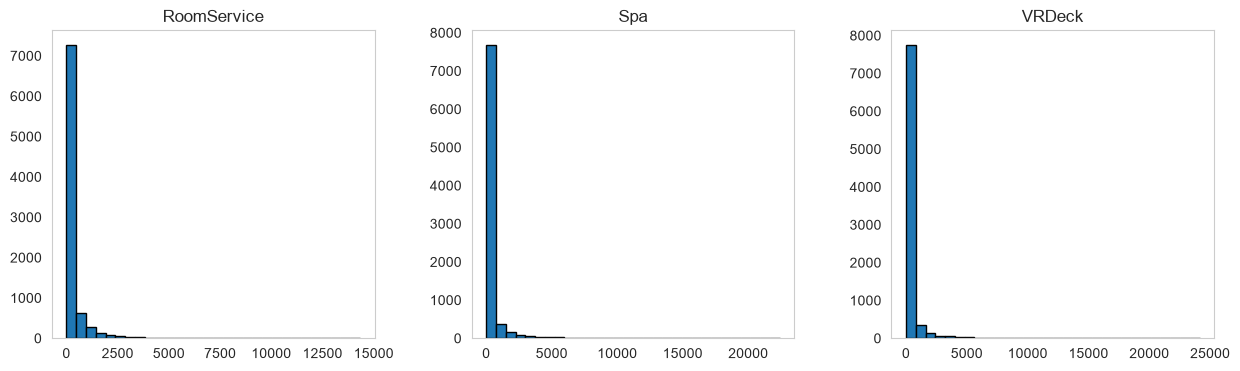

In [27]:
# YOUR CODE: create at least two exploratory plots
df[['RoomService', 'Spa', 'VRDeck']].hist(layout=(1, 3), figsize=(15, 4), grid=False, edgecolor='black', bins=30)

<Axes: xlabel='HomePlanet'>

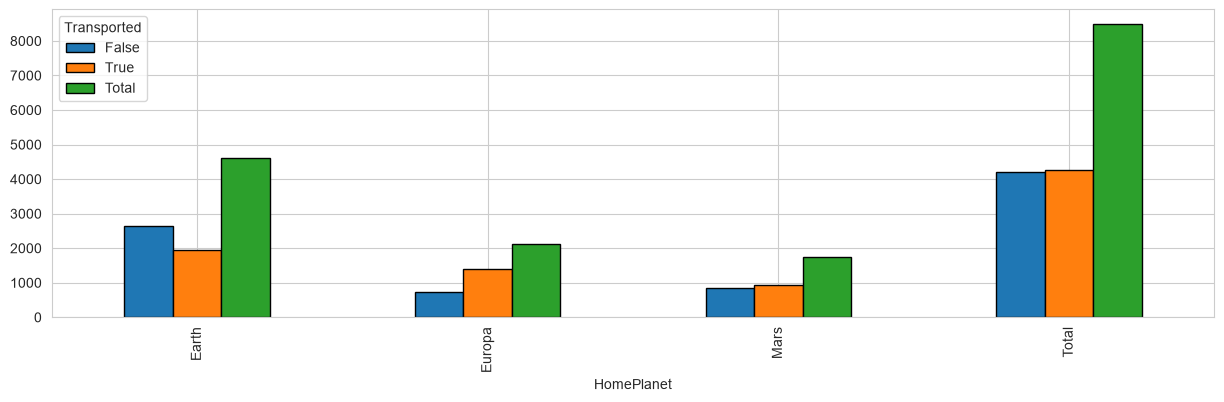

In [34]:
counts_table = pd.crosstab(df['HomePlanet'], df['Transported'], margins=True, margins_name='Total')
counts_table.plot(kind='bar', figsize=(15, 4), edgecolor='black')

<Axes: >

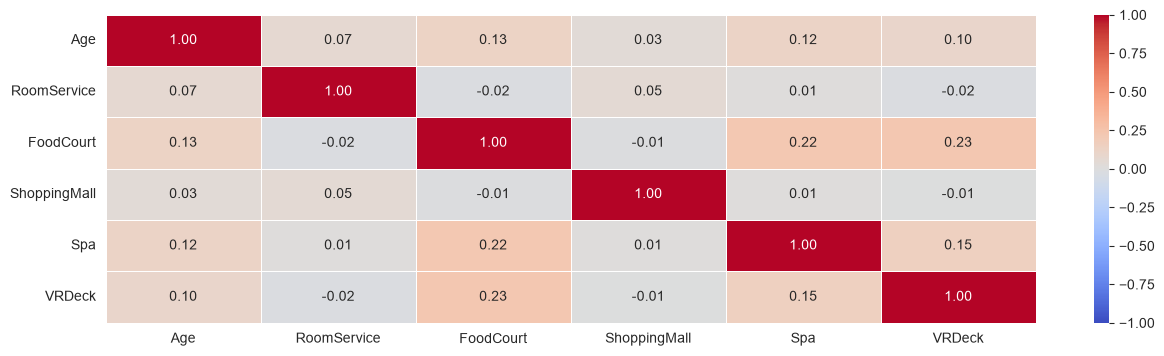

In [30]:
numerical_df = df.select_dtypes(include=['number'])
corr_matrix = numerical_df.corr()
plt.figure(figsize=(15, 4))

# 4. Create the heatmap using seaborn
sns.heatmap(corr_matrix, 
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            vmin=-1, vmax=1,
            linewidths=0.5)  

<Axes: >

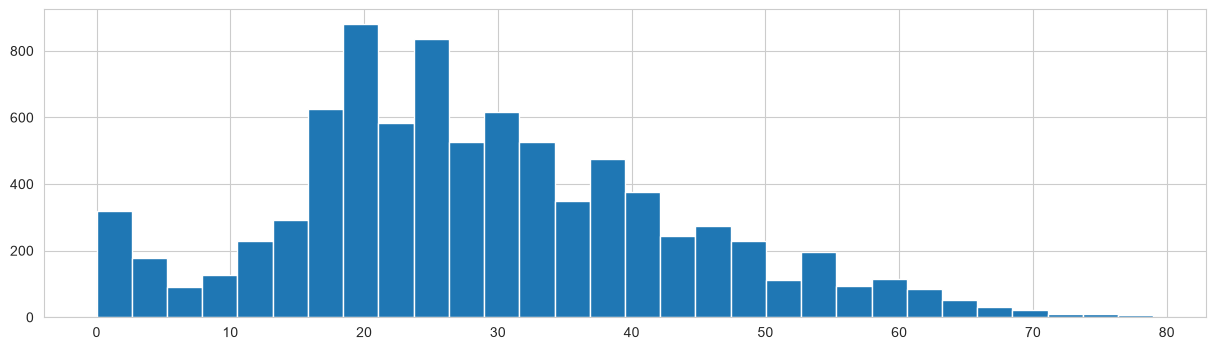

In [41]:
df['Age'].hist(figsize=(15, 4), bins=30)

**Q4:** Write down three observations about the data. These could be about distributions, relationships between features, or anything that surprises you.

---
## Part 2: Clean & Prepare

### 2.1 Feature engineering from `Cabin`

The `Cabin` column contains values like `B/0/P` (deck/number/side). This code splits it into three new features for you: parsing strings like this is fiddly, so we've done it here.

In [42]:
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')
df = df.drop(columns=['Cabin'])

**Q5:** Why might deck and side be more useful to a model than the raw cabin string?

### 2.2 Handle the `Name` and `PassengerId` columns

`PassengerId` has the format `groupId_memberNum`. We extract group size as a feature: passengers traveling in groups might behave differently. The name itself isn't useful for prediction.

In [43]:
df['GroupId'] = df['PassengerId'].str.split('_').str[0]
df['GroupSize'] = df.groupby('GroupId')['GroupId'].transform('count')
df = df.drop(columns=['PassengerId', 'Name', 'GroupId'])

### 2.3 Handle missing values

Impute the missing values using an appropriate strategy for each type of feature. Think about:
- What's the right fill value for **numerical** features like `Age` and spending columns? (Hint: these distributions are skewed.)
- What about **categorical** features like `HomePlanet` and `Destination`?
- And **boolean** features like `CryoSleep` and `VIP`?

**Hint:** `df.select_dtypes(include='number')` selects numerical columns. Same pattern for `'object'` and `'bool'`. Use `.fillna()` with your chosen strategy.

In [44]:
pd.set_option('future.no_silent_downcasting', True)

# YOUR CODE: impute missing values for numerical, categorical, and boolean columns
# Step 1: identify the column groups
# Step 2: fill missing values with an appropriate strategy for each group
# Step 3: verify no missing values remain with df.isnull().sum().sum()


/var/folders/dx/332tk2gs7yvgmlfx214z8wp00000gn/T/ipykernel_1297/479262364.py:1: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [45]:
df.select_dtypes(include=['number']).columns

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'CabinNum', 'GroupSize'],
      dtype='str')

In [46]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spending_cols:
    df[col] = df[col].fillna(0)

In [48]:
df['Age'] = df.groupby(['HomePlanet', 'VIP'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Age'] = df['Age'].fillna(df['Age'].median())

**Q6:** Why is median often preferred over mean for numerical imputation? Can you think of a case where this strategy might mislead the model?

### 2.4 Encode categorical variables

Convert the categorical columns (`HomePlanet`, `Destination`, `Deck`, `Side`) into a format the model can use. Use one-hot encoding.

**Hint:** `pd.get_dummies()` does this in one line. Use `drop_first=True` to avoid multicollinearity.

In [49]:
# YOUR CODE: one-hot encode the categorical columns
columns_to_encode = ['HomePlanet', 'Destination', 'Deck', 'Side']
df_encoded = pd.get_dummies(df, columns=columns_to_encode, dtype=int)


### 2.5 Convert booleans

The `CryoSleep`, `VIP`, and `Transported` columns need to be converted to integers (0/1) for the models to use them.

**Note:** After imputation, these columns may have been cast to `object` dtype, so `select_dtypes(include='bool')` won't find them. Reference them by name instead.

In [57]:
# YOUR CODE: convert CryoSleep, VIP, and Transported to int
df_encoded[['CryoSleep', 'VIP', 'Transported']] = df[['CryoSleep', 'VIP', 'Transported']].astype('Int64')

### 2.6 Split the data

Split the data into train, validation, and test sets. Use a 70/15/15 split.

**Important:** Split before any scaling to avoid data leakage. Use `stratify=y` to keep class proportions consistent across splits.

**Hint:** You'll need to call `train_test_split` twice: once to separate the test set, once to separate validation from train.

In [58]:
# YOUR CODE: 
# Step 1: separate features (X) from target (y)
# Step 2: split into train and temp (70/30)
# Step 3: split temp into validation and test (50/50 of the 30% = 15/15)
# Step 4: print the sizes to verify
X = df_encoded.drop(columns=['Transported'])
y = df_encoded['Transported']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train set shape:      {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape:       {X_test.shape}")

Train set shape:      (6085, 26)
Validation set shape: (1304, 26)
Test set shape:       (1304, 26)


**Q7:** Why do we pass `stratify=y`? What could go wrong if we didn't?

---
## Part 3: Model & Compare

### 3.1 Baseline: Random Forest

Train a `RandomForestClassifier` from scikit-learn on the training data and evaluate it on the validation set.

Steps:
1. Create a `RandomForestClassifier` with `n_estimators=100` and `random_state=42`
2. Fit it on `X_train` and `y_train`
3. Generate predictions and predicted probabilities on the validation set
4. Print the `classification_report` and `roc_auc_score`

**Hint:** Use `.predict()` for class predictions and `.predict_proba(X_val)[:, 1]` for the probability of the positive class (needed for AUC).

In [59]:
# YOUR CODE: train a Random Forest and evaluate on the validation set
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [75]:
y_pred = rf_model.predict(X_val)
y_pred_prob = rf_model.predict_proba(X_val)[:, 1]

In [69]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.78      0.85      0.81       648
         1.0       0.84      0.76      0.80       656

    accuracy                           0.80      1304
   macro avg       0.81      0.80      0.80      1304
weighted avg       0.81      0.80      0.80      1304



In [72]:
auc_score = roc_auc_score(y_val, y_pred_prob)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.8867


### 3.2 Gradient Boosting: XGBoost

Now train an `XGBClassifier` and compare it to your Random Forest.

Use these starting hyperparameters:
- `n_estimators=200`
- `learning_rate=0.1`
- `max_depth=5`
- `random_state=42`
- `eval_metric='logloss'`

Evaluate on the validation set the same way you did for the Random Forest.

In [73]:
# YOUR CODE: train an XGBoost model and evaluate on the validation set
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [76]:
xgb_y_pred = xgb_model.predict(X_val)
xgb_y_pred_prob = xgb_model.predict_proba(X_val)[:, 1]

In [77]:
print(classification_report(y_val, xgb_y_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.83      0.82       648
         1.0       0.83      0.82      0.82       656

    accuracy                           0.82      1304
   macro avg       0.82      0.82      0.82      1304
weighted avg       0.82      0.82      0.82      1304



In [79]:
auc_score = roc_auc_score(y_val, xgb_y_pred_prob)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.9147


**Q8:** Which model performs better on the validation set? Look at precision, recall, and AUC: not just accuracy.

### 3.3 Quick hyperparameter tuning

Here's a random search over a few XGBoost hyperparameters. Run it and see if tuning improves on your default XGBoost.

In [80]:
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05}
Best CV AUC: 0.8915


### 3.4 Evaluate the best model on the test set

Use your best model (whichever performed best) on the held-out test set. **This is the only time you touch the test set.**

Print the `classification_report` and `roc_auc_score` for the test set.

In [82]:
# YOUR CODE: evaluate the best model on X_test / y_test
# Hint: search.best_estimator_ gives you the best model from the random search
xgb_y_pred_test = search.best_estimator_.predict(X_test)
xgb_y_pred_test_prob = search.best_estimator_.predict_proba(X_test)[:, 1]

In [83]:
print(classification_report(y_test, xgb_y_pred_test))

              precision    recall  f1-score   support

         0.0       0.78      0.82      0.80       647
         1.0       0.81      0.78      0.79       657

    accuracy                           0.80      1304
   macro avg       0.80      0.80      0.80      1304
weighted avg       0.80      0.80      0.80      1304



In [84]:
auc_score = roc_auc_score(y_test, xgb_y_pred_test_prob)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.8947


---
## Part 4: Interpret & Reflect

### 4.1 Feature importance

Plot a horizontal bar chart of the top 15 most important features from your best model.

**Hint:** Your model has a `.feature_importances_` attribute. Combine it with `X_train.columns` into a `pd.Series`, sort it, and use `.plot(kind='barh')`.

/var/folders/dx/332tk2gs7yvgmlfx214z8wp00000gn/T/ipykernel_1297/1745163225.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df.head(15),


<Axes: xlabel='Importance', ylabel='Feature'>

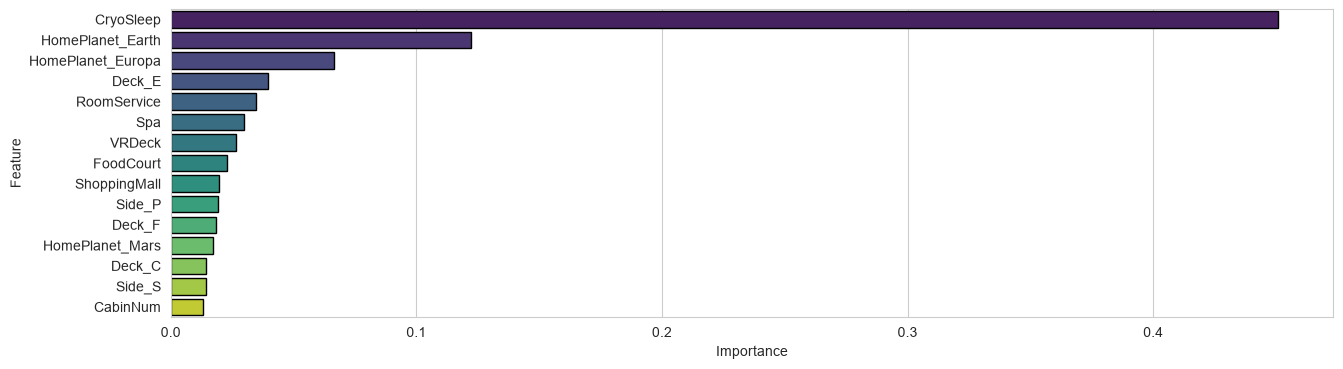

In [88]:
# YOUR CODE: plot the top 15 feature importances
importances = xgb_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(15, 4))
sns.barplot(data=feature_imp_df.head(15),
            x='Importance', 
            y='Feature', 
            palette='viridis', 
            edgecolor='black')

**Q9:** Which features matter most? Is there anything surprising? Does anything from your EDA in Part 1 help explain these importances?

### 4.2 Confusion matrix

Plot a confusion matrix for your best model's test set predictions.

**Hint:** Use `confusion_matrix()` from sklearn and `sns.heatmap()` to visualize it. Label your axes as 'Not Transported' and 'Transported'.

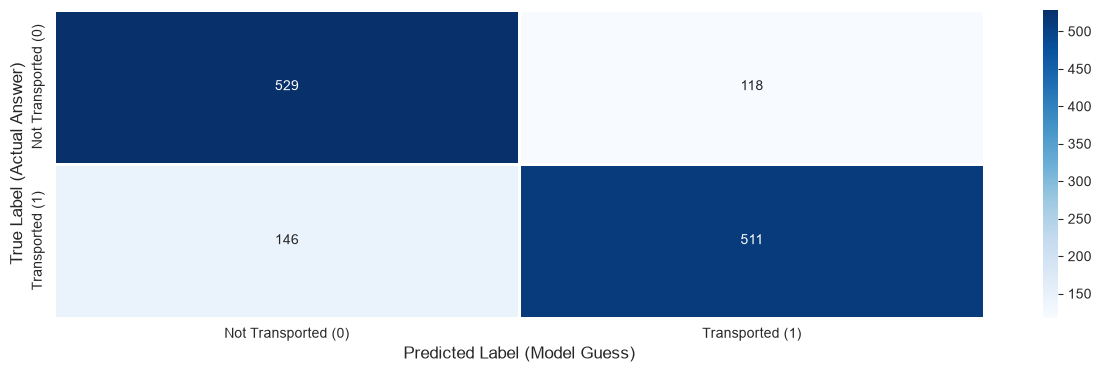

In [90]:
# YOUR CODE: plot the confusion matrix
cm = confusion_matrix(y_test, xgb_y_pred_test)

plt.figure(figsize=(15, 4))
sns.heatmap(cm, 
            annot=True,
            fmt="d",
            cmap="Blues",
            linewidths=1,
            xticklabels=['Not Transported (0)', 'Transported (1)'],
            yticklabels=['Not Transported (0)', 'Transported (1)'])

plt.xlabel('Predicted Label (Model Guess)', fontsize=12)
plt.ylabel('True Label (Actual Answer)', fontsize=12)
plt.show()

**Q10:** Where does the model make more mistakes: false positives or false negatives? In a real-world version of this problem, which type of error would be worse?